In [ ]:
PROJECT TITLE:
Supermarket Sales Analysis 

AUTHOR:
AEDULAPURAM MANIDEEP

INTERNSHIP:
AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026

OBJECTIVE:
To analyze supermarket sales data, identify business insights, and build a machine learning model to predict sales.

First 5 Rows:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905       26.14

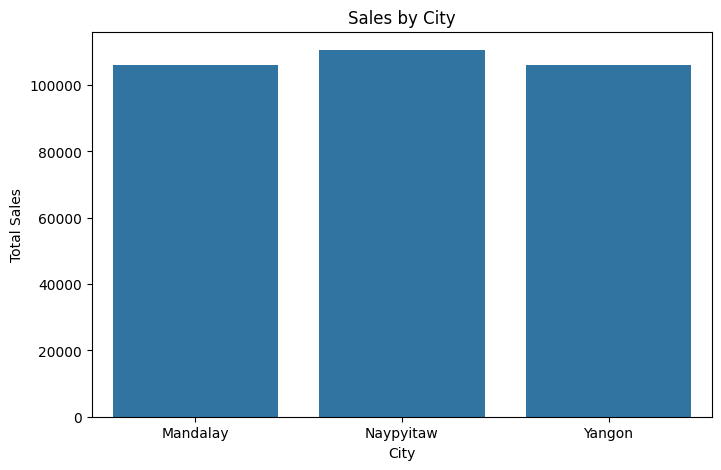

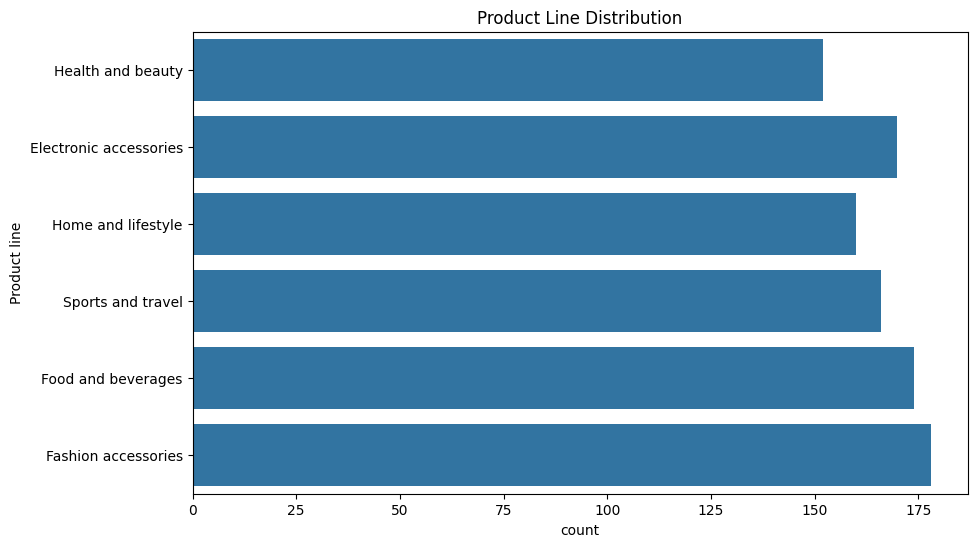

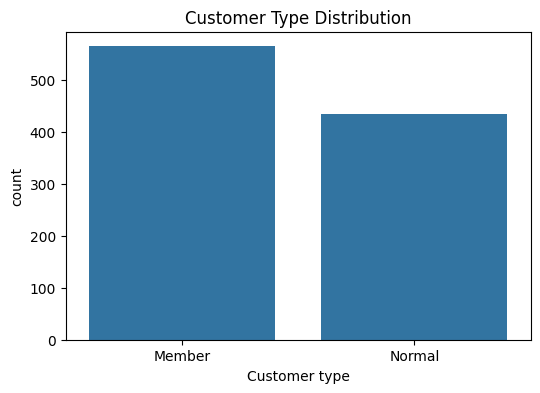

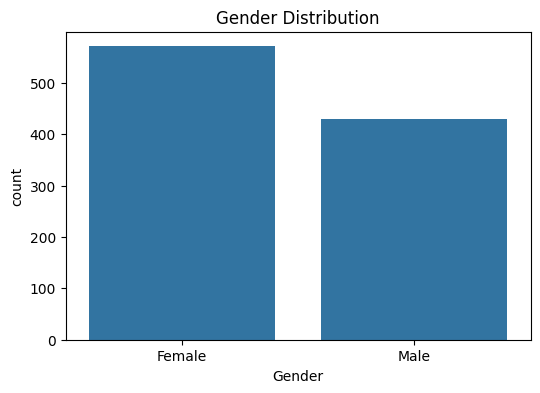

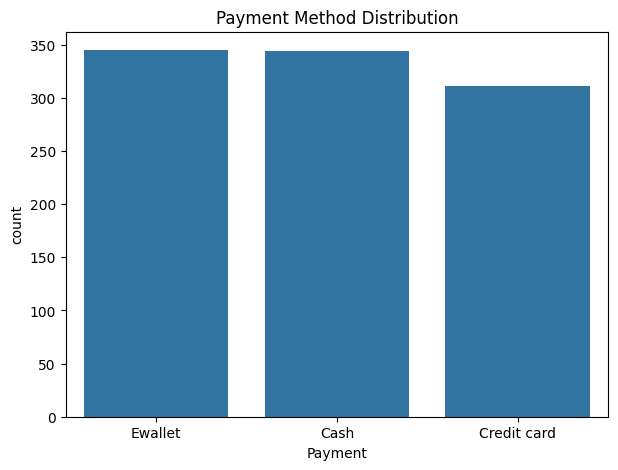

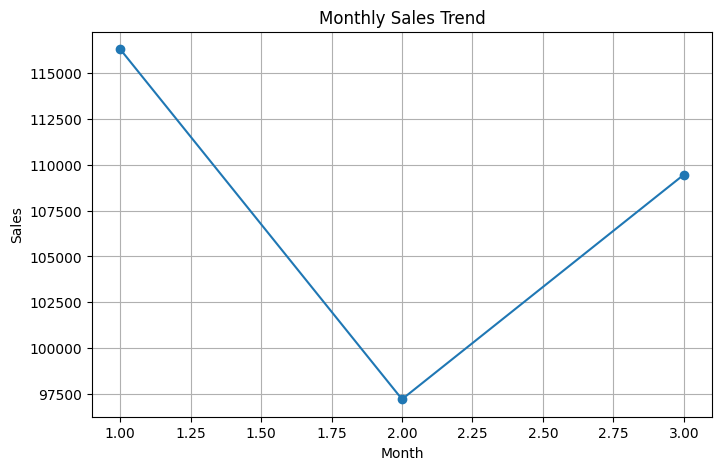

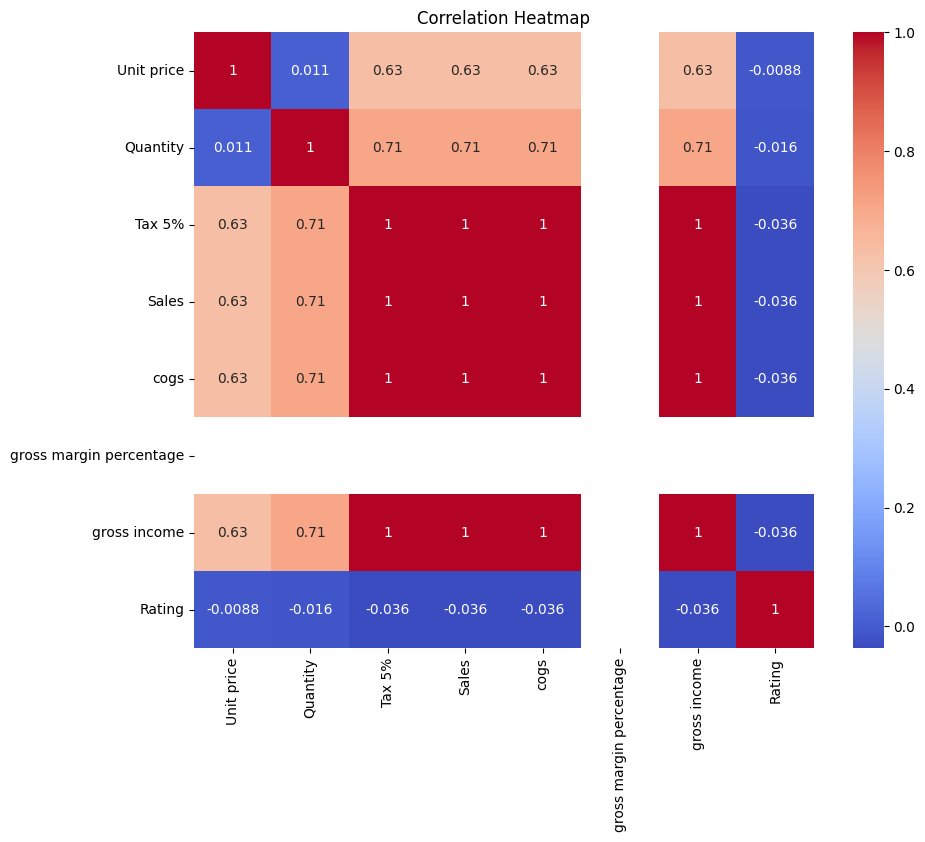


Model Performance
------------------
MAE = 0.8239014000000177
MSE = 2.105942710977017
R2 Score = 0.9999676302662849


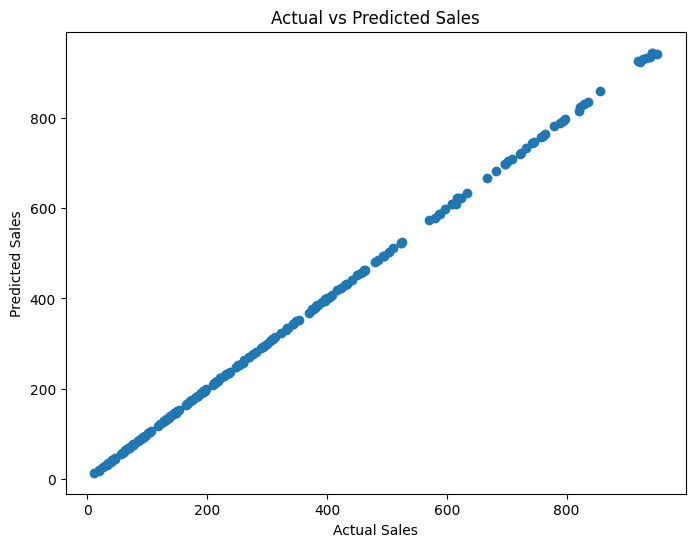


Top Features:
                    Feature  Importance
8                      cogs    0.999905
5                Unit price    0.000034
10                   Rating    0.000017
4              Product line    0.000012
7                   Payment    0.000008
2             Customer type    0.000007
0                    Branch    0.000005
1                      City    0.000005
6                  Quantity    0.000004
3                    Gender    0.000003
9   gross margin percentage    0.000000

PROJECT COMPLETED

KEY FINDINGS

1. Sales trends analyzed successfully.
2. Product line performance identified.
3. Customer purchasing behavior studied.
4. Payment methods analyzed.
5. Correlation between variables examined.
6. Random Forest model built for sales prediction.
7. Model performance evaluated using MAE, MSE and R² Score.



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(
    r"C:\Users\manid\Downloads\archive\SuperMarket Analysis.csv"
)
print("First 5 Rows:")
print(df.head())
print("\nDataset Information:")
df.info()
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
print("\nDataset Shape:")
print(df.shape)
city_sales = df.groupby("City")["Sales"].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(
    data=city_sales,
    x="City",
    y="Sales"
)

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="Product line"
)

plt.title("Product Line Distribution")
plt.show()
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Customer type"
)

plt.title("Customer Type Distribution")
plt.show()
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender"
)
plt.title("Gender Distribution")
plt.show()
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x="Payment"
)
plt.title("Payment Method Distribution")
plt.show()
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = df.groupby(
    df["Date"].dt.month
)["Sales"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()
df_ml = df.copy()

encoder = LabelEncoder()

categorical_columns = [
    "Branch",
    "City",
    "Customer type",
    "Gender",
    "Product line",
    "Payment"
]

for col in categorical_columns:
    df_ml[col] = encoder.fit_transform(df_ml[col])
X = df_ml.drop(
    [
        "Invoice ID",
        "Date",
        "Time",
        "Tax 5%",
        "Sales",
        "gross income"
    ],
    axis=1
)

y = df_ml["Sales"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("\nModel Performance")
print("------------------")
print("MAE =", mae)
print("MSE =", mse)
print("R2 Score =", r2)
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features:")
print(feature_importance)
print("""
PROJECT COMPLETED

KEY FINDINGS

1. Sales trends analyzed successfully.
2. Product line performance identified.
3. Customer purchasing behavior studied.
4. Payment methods analyzed.
5. Correlation between variables examined.
6. Random Forest model built for sales prediction.
7. Model performance evaluated using MAE, MSE and R² Score.
""")